# Conexión y carga de datos EOD

In [106]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt

# Ruta a la base Access de la EOD 2012
DB = r"C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\DATOS\EOD\EOD GRAN SANTIAGO\base_datos_eodStgo_2012\base_datos_eodStgo_2012.accdb"

# Conexión ODBC
cn = pyodbc.connect(
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};DBQ=" + DB + ";"
)

# Consulta base:
# - población de 60 años o más
# - viajes con propósito, modo, factor de expansión y variables sociodemográficas

q = """
SELECT
  V.Hogar,
  V.Persona,
  V.Viaje,

  V.OrigenCoordX,
  V.OrigenCoordY,
  V.DestinoCoordX,
  V.DestinoCoordY,

  V.SectorOrigen,
  V.SectorDestino,

  V.HoraIni,
  V.HoraFin,
  V.TiempoViaje AS reported_travel_min,

  V.PropositoAgregado,
  PA.PropositoEstraus AS PropositoAggTxt,

  V.Proposito,
  P2.Proposito AS PropositoTxt,

  V.ModoAgregado,
  MA.Modo AS ModoAggTxt,

  V.FactorLaboralNormal,
  V.FactorSabadoNormal,
  V.FactorDomingoNormal,
  V.FactorLaboralEstival,
  V.FactorFindesemanaEstival,

  IIf(Not IsNull(V.FactorLaboralNormal), 'laboral_normal',
    IIf(Not IsNull(V.FactorSabadoNormal), 'sabado_normal',
      IIf(Not IsNull(V.FactorDomingoNormal), 'domingo_normal',
        IIf(Not IsNull(V.FactorLaboralEstival), 'laboral_estival',
          IIf(Not IsNull(V.FactorFindesemanaEstival), 'findesemana_estival', 'sin_factor')
        )
      )
    )
  ) AS TipoDiaFactor,

  IIf(Not IsNull(V.FactorLaboralNormal), V.FactorLaboralNormal,
    IIf(Not IsNull(V.FactorSabadoNormal), V.FactorSabadoNormal,
      IIf(Not IsNull(V.FactorDomingoNormal), V.FactorDomingoNormal,
        IIf(Not IsNull(V.FactorLaboralEstival), V.FactorLaboralEstival,
          IIf(Not IsNull(V.FactorFindesemanaEstival), V.FactorFindesemanaEstival, Null)
        )
      )
    )
  ) AS FactorExpansion,

  V.Periodo,
  Pe.Periodos AS PeriodoTxt,

  P.Sexo,
  P.AnoNac,
  (2012 - P.AnoNac) AS Edad,
  P.Estudios,
  P.TramoIngreso

FROM
  (((([Viaje] AS V
    LEFT JOIN [PropositoAgregado] AS PA
      ON V.PropositoAgregado = PA.Id)
    LEFT JOIN [Proposito] AS P2
      ON V.Proposito = P2.Id)
    LEFT JOIN [Periodo] AS Pe
      ON V.Periodo = Pe.Id)
    LEFT JOIN [Modo Agregado] AS MA
      ON V.ModoAgregado = MA.ID)
    LEFT JOIN [Persona] AS P
      ON (V.Hogar = P.Hogar AND V.Persona = P.Persona)

WHERE
  (2012 - P.AnoNac) >= 60
"""

# Lectura a pandas
df = pd.read_sql(q, cn)

print("Dimensión base:", df.shape)
print(df["TipoDiaFactor"].value_counts(dropna=False))
print("Proporción de NA en FactorExpansion:", df["FactorExpansion"].isna().mean())
print(df["ModoAggTxt"].value_counts(normalize=True).head(10))

C:\Users\mbell\AppData\Local\Temp\ipykernel_22568\903550937.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, cn)


Dimensión base: (18406, 32)
TipoDiaFactor
laboral_normal         12166
laboral_estival         2494
sabado_normal           1586
domingo_normal          1321
findesemana_estival      838
sin_factor                 1
Name: count, dtype: int64
Proporción de NA en FactorExpansion: 5.433010974682169e-05
ModoAggTxt
Caminata          0.367326
Auto              0.220200
Bus TS            0.167880
Metro             0.050799
Bus TS - Metro    0.044496
Taxi Colectivo    0.041726
Taxi              0.027002
Bicicleta         0.025481
Bus no TS         0.023090
Otros             0.010975
Name: proportion, dtype: float64


# 2. Filtrado del escenario analítico

In [107]:
# Se trabaja solo con días laborales normales para evitar mezclar universos de expansión
df_lab = df[df["TipoDiaFactor"] == "laboral_normal"].copy()

print("Dimensión laboral_normal:", df_lab.shape)

Dimensión laboral_normal: (12166, 32)


In [121]:
df_lab['ModoAggTxt'].unique()

array(['Taxi Colectivo', 'Bus no TS', 'Bicicleta', 'Otros', 'Caminata',
       'Auto', 'Bus TS', 'Taxi ', 'Bus TS - Metro', 'Otros - Bus TS',
       'Bus TS - Bus no TS', 'Otros - Bus TS - Metro', 'Metro',
       'Bus no TS - Metro', 'Otros - Metro', 'Taxi Colectivo - Metro',
       'Taxi - Metro', 'Auto - Metro'], dtype=object)

# 3. Recodificación de propósito y modo

In [122]:
# Recodificación de propósitos a grupos más interpretables para el análisis
def agrupar_proposito(p):
    p = str(p).strip().lower()

    if p == "volver a casa":
        return "retorno"
    elif p == "de salud":
        return "salud"
    elif p in ["de compras", "trámites", "buscar o dejar algo"]:
        return "compras_tramites"
    elif p in ["recreación", "visitar a alguien", "buscar o dejar a alguien", "comer o tomar algo"]:
        return "social_recreacion"
    elif p in ["al trabajo", "por trabajo"]:
        return "trabajo"
    elif p in ["al estudio", "por estudio"]:
        return "estudio"
    else:
        return "otros"

df_lab["purpose_group"] = df_lab["PropositoTxt"].apply(agrupar_proposito)


# Recodificación de modos a categorías más agregadas
def agrupar_modo(m):
    m = str(m).strip()

    if m == "Caminata":
        return "caminata_pura"
    elif m == "Bicicleta":
        return "bicicleta"
    elif m == "Auto":
        return "auto"
    elif "Bus" in m or "Metro" in m:
        return "transporte_publico"
    elif "Taxi" in m:
        return "taxi_colectivo"
    else:
        return "otros"

df_lab["modo_group"] = df_lab["ModoAggTxt"].apply(agrupar_modo)

## 4. Variables de agrupación sociodemográfica y proxy de vulnerabilidad

In [123]:
# Grupos etarios
df_lab["grupo_edad"] = pd.cut(
    df_lab["Edad"],
    bins=[60, 70, 80, 100],
    labels=["60-70", "70-80", "80+"]
)

# Grupos de educación
df_lab["educ_group"] = pd.cut(
    df_lab["Estudios"],
    bins=[0, 4, 8, 12],
    labels=["baja", "media", "alta"]
)

# Proxy simple de vulnerabilidad individual
# Nota: esta es una aproximación preliminar, luego puede refinarse
df_lab["vuln_proxy"] = (
    df_lab["Edad"] * 0.3 +
    (df_lab["Estudios"].max() - df_lab["Estudios"]) * 0.4 +
    df_lab["TramoIngreso"] * 0.3
)

df_lab["vuln_group"] = pd.qcut(
    df_lab["vuln_proxy"],
    3,
    labels=["baja", "media", "alta"]
)

print(df_lab["vuln_group"].value_counts(normalize=True))

vuln_group
baja     0.347361
alta     0.331991
media    0.320648
Name: proportion, dtype: float64


# 5. Resultados principales
## 5.1 Propósitos de viaje por grupo de vulnerabilidad

C:\Users\mbell\AppData\Local\Temp\ipykernel_22568\1127735045.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vuln = df_vuln / df_vuln.groupby(level=0).sum()


vuln_group  purpose_group    
baja        compras_tramites     0.227226
            estudio              0.001904
            otros                0.022504
            retorno              0.452110
            salud                0.039928
            social_recreacion    0.094628
            trabajo              0.161700
media       compras_tramites     0.259515
            estudio              0.001066
            otros                0.021566
            retorno              0.463259
            salud                0.045571
            social_recreacion    0.077184
            trabajo              0.131839
alta        compras_tramites     0.301068
            estudio              0.001229
            otros                0.023176
            retorno              0.473201
            salud                0.075424
            social_recreacion    0.072194
            trabajo              0.053708
Name: FactorExpansion, dtype: float64


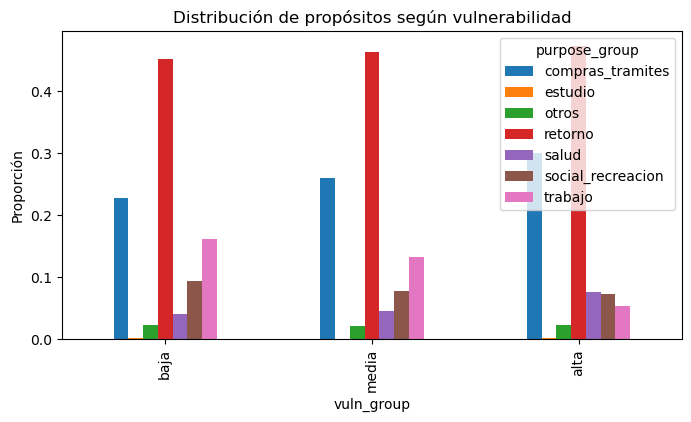

In [124]:
df_vuln = (
    df_lab.groupby(["vuln_group", "purpose_group"], observed=False)["FactorExpansion"]
    .sum()
)

df_vuln = df_vuln / df_vuln.groupby(level=0).sum()

print(df_vuln)

ax = df_vuln.unstack().plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribución de propósitos según vulnerabilidad")
ax.set_ylabel("Proporción")
plt.show()

## 5.2 Modos según vulnerabilidad

vuln_group  modo_group        
baja        auto                  0.303236
            bicicleta             0.033434
            caminata_pura         0.334690
            otros                 0.007543
            taxi_colectivo        0.059173
            transporte_publico    0.261923
media       auto                  0.210565
            bicicleta             0.027255
            caminata_pura         0.408800
            otros                 0.009318
            taxi_colectivo        0.071936
            transporte_publico    0.272126
alta        auto                  0.159870
            bicicleta             0.023343
            caminata_pura         0.485929
            otros                 0.011589
            taxi_colectivo        0.101020
            transporte_publico    0.218249
Name: FactorExpansion, dtype: float64


C:\Users\mbell\AppData\Local\Temp\ipykernel_22568\1810645038.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modo = df_modo / df_modo.groupby(level=0).sum()


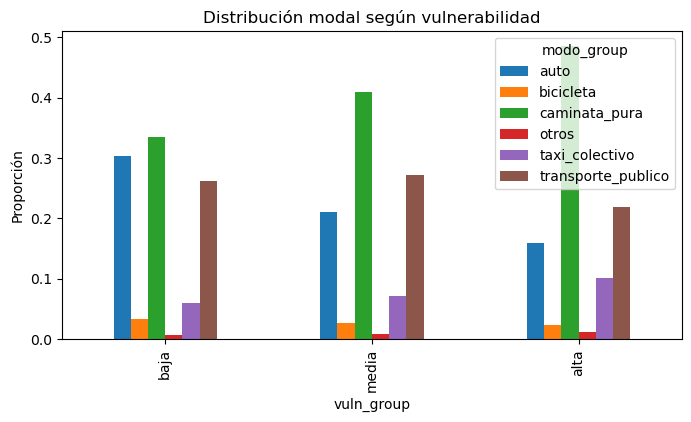

In [125]:
df_modo = (
    df_lab.groupby(["vuln_group", "modo_group"], observed=False)["FactorExpansion"]
    .sum()
)

df_modo = df_modo / df_modo.groupby(level=0).sum()

print(df_modo)

ax = df_modo.unstack().plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribución modal según vulnerabilidad")
ax.set_ylabel("Proporción")
plt.show()

## 5.3 Tiempo de viaje según vulnerabilidad

vuln_group
baja     35.110742
media    35.191784
alta     29.707517
Name: reported_travel_min, dtype: float64


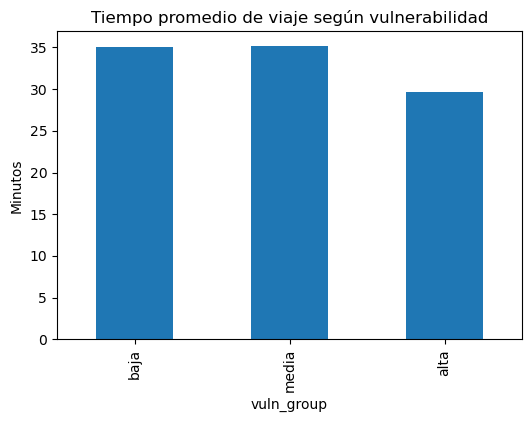

In [126]:
tiempo_viaje = df_lab.groupby("vuln_group", observed=False)["reported_travel_min"].mean()
print(tiempo_viaje)

ax = tiempo_viaje.plot(kind="bar", figsize=(6, 4))
ax.set_title("Tiempo promedio de viaje según vulnerabilidad")
ax.set_ylabel("Minutos")
plt.show()

## 5.4 Viajes no motorizados según vulnerabilidad

vuln_group  purpose_group    
alta        compras_tramites     0.378075
            estudio              0.001140
            otros                0.023994
            retorno              0.477973
            salud                0.028884
            social_recreacion    0.072372
            trabajo              0.017562
baja        compras_tramites     0.348411
            estudio              0.000815
            otros                0.026701
            retorno              0.458872
            salud                0.016065
            social_recreacion    0.089092
            trabajo              0.060045
media       compras_tramites     0.353777
            estudio              0.000555
            otros                0.024830
            retorno              0.468129
            salud                0.021135
            social_recreacion    0.077327
            trabajo              0.054248
Name: FactorExpansion, dtype: float64


C:\Users\mbell\AppData\Local\Temp\ipykernel_22568\2489640675.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mix_norm = df_mix / df_mix.groupby(level=[0, 1]).sum()


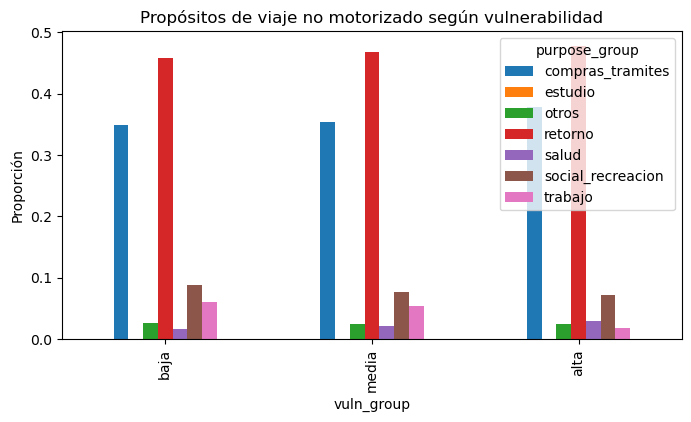

In [128]:
df_mix = (
    df_lab.groupby(["vuln_group", "modo_group", "purpose_group"], observed=False)["FactorExpansion"]
    .sum()
)

# Normalización por vulnerabilidad + modo
df_mix_norm = df_mix / df_mix.groupby(level=[0, 1]).sum()

# Se visualiza solo el modo no motorizado, que es el más relevante para el paper
df_walk = df_mix_norm.xs("caminata_pura", level="modo_group")

print(df_walk)

ax = df_walk.unstack().plot(kind="bar", figsize=(8, 4))
ax.set_title("Propósitos de viaje no motorizado según vulnerabilidad")
ax.set_ylabel("Proporción")
plt.show()

In [140]:
df_walk = df_lab[df_lab["ModoAggTxt"] == "Caminata"].copy()

# Nos quedamos solo con los propósitos que sí usaremos en la simulación
purposes_keep = ["salud", "compras_tramites", "social_recreacion"]
df_walk = df_walk[df_walk["purpose_group"].isin(purposes_keep)].copy()

print("Dimensión df_walk:", df_walk.shape)
print(df_walk["purpose_group"].value_counts(normalize=True))

Dimensión df_walk: (2049, 38)
purpose_group
compras_tramites     0.775012
social_recreacion    0.172279
salud                0.052709
Name: proportion, dtype: float64


In [141]:
# Nos quedamos solo con los propósitos que sí usaremos en la simulación
purposes_keep = ["salud", "compras_tramites", "social_recreacion"]
df_walk = df_walk[df_walk["purpose_group"].isin(purposes_keep)].copy()

print("Dimensión df_walk:", df_walk.shape)
print(df_walk["purpose_group"].value_counts(normalize=True))

Dimensión df_walk: (2049, 38)
purpose_group
compras_tramites     0.775012
social_recreacion    0.172279
salud                0.052709
Name: proportion, dtype: float64


In [142]:
# -------------------------------------------------------------------
# 8. Tabla B: probabilidad de propósito dado caminata pura y vulnerabilidad
# -------------------------------------------------------------------

tabla_purpose_prob = (
    df_walk.groupby(["vuln_group", "purpose_group"], observed=False)["FactorExpansion"]
    .sum()
    .reset_index(name="n_expand")
)

tabla_purpose_prob["prob"] = (
    tabla_purpose_prob.groupby("vuln_group")["n_expand"]
    .transform(lambda x: x / x.sum())
)

print(tabla_purpose_prob)

  vuln_group      purpose_group    n_expand      prob
0       baja   compras_tramites  633.793235  0.768157
1       baja              salud   29.224046  0.035420
2       baja  social_recreacion  162.066159  0.196424
3      media   compras_tramites  729.453542  0.782280
4      media              salud   43.577654  0.046734
5      media  social_recreacion  159.440175  0.170987
6       alta   compras_tramites  982.893311  0.788757
7       alta              salud   75.089460  0.060258
8       alta  social_recreacion  188.147389  0.150985


C:\Users\mbell\AppData\Local\Temp\ipykernel_22568\2232081421.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_purpose_prob.groupby("vuln_group")["n_expand"]


In [143]:
# -------------------------------------------------------------------
# 9. Tabla C: resumen de tiempos de viaje caminando
# -------------------------------------------------------------------

tabla_tiempos = (
    df_walk.groupby(["vuln_group", "purpose_group"], observed=False)["reported_travel_min"]
    .agg(
        n="count",
        mean_time="mean",
        median_time="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

print(tabla_tiempos)

  vuln_group      purpose_group    n  mean_time  median_time   p25   p75
0       baja   compras_tramites  429  11.624709         10.0   5.0  15.0
1       baja              salud   22  18.045455         15.0  10.0  25.0
2       baja  social_recreacion  113  14.761062         10.0   5.0  20.0
3      media   compras_tramites  494  12.773279         10.0   5.0  15.0
4      media              salud   31  20.193548         15.0  12.5  27.5
5      media  social_recreacion  111  14.603604         10.0   6.5  20.0
6       alta   compras_tramites  665  12.634586         10.0   5.0  15.0
7       alta              salud   55  18.709091         15.0  10.0  25.0
8       alta  social_recreacion  129  20.596899         15.0  10.0  20.0


In [148]:
tabla_walk_prob = (
    df_lab.assign(es_caminata_pura = df_lab["ModoAggTxt"] == "Caminata")
    .groupby("vuln_group", observed=False)
    .apply(lambda g: pd.Series({
        "n_expand_total": g["FactorExpansion"].sum(),
        "n_expand_walk": g.loc[g["es_caminata_pura"], "FactorExpansion"].sum(),
        "p_walk_pure": g.loc[g["es_caminata_pura"], "FactorExpansion"].sum() / g["FactorExpansion"].sum()
    }))
    .reset_index()
)

tabla_walk_prob

C:\Users\mbell\AppData\Local\Temp\ipykernel_22568\3370755556.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,vuln_group,n_expand_total,n_expand_walk,p_walk_pure
0,baja,5435.166627,1819.096319,0.334690
1,media,5043.790750,2061.902945,0.408800
2,alta,5350.015259,2599.728057,0.485929


In [149]:
from pathlib import Path

OUT_DIR = Path("../data/processed/eod")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Probabilidad de caminar puro
tabla_walk_prob.to_csv(
    OUT_DIR / "tabla_walk_prob.csv",
    index=False
)

# 2. Probabilidad de propósito
tabla_purpose_prob.to_csv(
    OUT_DIR / "tabla_purpose_prob.csv",
    index=False
)

# 3. Tiempos de caminata
tabla_tiempos.to_csv(
    OUT_DIR / "tabla_tiempos_caminata.csv",
    index=False
)

# 4. Pivot opcional para revisión
tabla_pivot = tabla_purpose_prob.pivot(
    index="vuln_group",
    columns="purpose_group",
    values="prob"
)

tabla_pivot.to_csv(OUT_DIR / "tabla_purpose_prob_pivot.csv")

print("Tablas EOD exportadas correctamente")

Tablas EOD exportadas correctamente
